In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle, re, collections, shutil
from functools import reduce

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings
warnings.filterwarnings("ignore")

from matplotlib.ticker import FormatStrFormatter
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
import statsmodels.stats.api as sm

sys.path.append("scripts")
from utils import *

# load all utils functions
os.chdir("../../")

data_utils_dir = "./data_processing/data_utils"
results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results" # change
MIC_data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs" # change

data_dir = "./analysis/TRUST/processed_data"

model_loci = pd.read_csv(f"{data_utils_dir}/drug_loci.csv")

# for survival analysis
import lifelines
from epi_utils import *
from datetime import datetime

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETO",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMK",
                  "Pretomanid": "PMD",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LFX",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {val: key for key, val in drug_abbr_dict.items()}

who_variants = pd.read_csv(f"{data_utils_dir}/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
silent_lst = ['synonymous_variant', 'initiator_codon_variant', 'stop_retained_variant']

TRUST_TRUST_isolate_variants = pd.read_csv(f"{data_dir}/isolate_variants_WHO_catalog.csv")

cc_df = pd.read_csv(f"{data_utils_dir}/drug_CC.csv")

MGIT_cc_dict = {'RIF': 0.5, 'EMB': 5, 'INH': 0.1, 'PZA': 100}

# MIC encoding from the TRUST codebook
MIC_encoding_dicts = {'RIF': {1: '0,0.03', 2: '0.03,0.06', 3: '0.06,0.125', 4: '0.125,0.25', 5: '0.25,0.5', 6: '0.5,1', 7: '1,inf'},
                      'INH': {1: '0,0.025', 2: '0.025,0.05', 3: '0.05,0.1', 4: '0.1,0.2', 5: '0.2,inf'},
                      'EMB': {1: '0,0.6', 2: '0.6,1.25', 3: '1.25,2.5', 4: '2.5,5', 5: '5,inf'},
                      'PZA': {1: '0,25', 2: '25,50', 3: '50,75', 4: '75,100', 5: '100,inf'}
                     }

RIF_label_encoding_dict = {1: '≤0.03', 2: '0.03-0.06', 3: '0.06-0.125', 4: '0.125-0.25', 5: '0.25-0.5', 6: '0.5-1', 7: '>1'}
INH_label_encoding_dict = {1: '≤0.025', 2: '0.025-0.05', 3: '0.05-0.1', 4: '0.1-0.2', 5: '>0.2'}
EMB_label_encoding_dict = {1: '≤0.6', 2: '0.6-1.25', 3: '1.25-2.5', 4: '2.5-5', 5: '>5'}
PZA_label_encoding_dict = {1: '≤25', 2: '25-50', 3: '50-75', 4: '75-100', 5: '>100'}

MIC_label_encoding_dicts = {'RIF': RIF_label_encoding_dict, 'INH': INH_label_encoding_dict, 'EMB': EMB_label_encoding_dict, 'PZA': PZA_label_encoding_dict}

final_keep_pids = pd.read_csv(f"{data_dir}/final_keep_pids.txt", sep='\t', header=None)[0].values

# Summarize Patient Demographics

In [2]:
df_all_TRUST_data = pd.read_csv("~/TRUST_data_processing/raw_data/TRUST_DATA_2025-05-12_1129.cleaned.wide.csv")
print(f"{df_all_TRUST_data.pid.nunique()} total pids")

df_unique_patients = df_all_TRUST_data.loc[pd.isnull(df_all_TRUST_data['screen_prevpid'])]
print(f"{df_unique_patients.pid.nunique()} unique patients")

458 total pids
440 unique patients


In [3]:
PLI_data = pd.read_csv(os.path.join(data_dir, "PLI_Timika_predictions.csv"))

missing_PLI_pids = list(set(df_all_TRUST_data.pid) - set(PLI_data.pid))
len(missing_PLI_pids)

7

In [4]:
# all_CXRs = pd.read_csv("/home/sak0914/all_CXRs.txt", sep='\t', header=None).rename(columns={0: 'fName'})
# all_CXRs['pid'] = [os.path.basename(fName).split('_')[0] for fName in all_CXRs['fName'].values]
# len(all_CXRs)

In [5]:
# set(missing_PLI_pids).intersection(all_CXRs['pid'])

In [6]:
len(df_unique_patients.loc[df_unique_patients['screen_sex']==1])/len(df_unique_patients)

0.6045454545454545

In [7]:
df_unique_patients[['bl_hiv', 'bl_prevtb', 'bl_medhx___5']].mean()

bl_hiv          0.280182
bl_prevtb       0.384091
bl_medhx___5    0.043182
dtype: float64

In [8]:
len(df_unique_patients.query("bl_bmi < 18")) / len(df_unique_patients)

0.5386363636363637

In [4]:
df_TTP_smear = pd.read_csv(os.path.join(data_dir, "TTP_smear_results.csv"))
df_TCC = pd.read_csv(os.path.join(data_dir, "TCC.csv"))
df_cultures = pd.read_csv(os.path.join(data_dir, "cultures.csv"))

print(f"{df_TCC.pid.nunique()} pids for the TCC analysis")
print(f"{df_TTP_smear.dropna(subset='culture_sample_num').query('culture_sample_num <= 2').pid.nunique()} pids with baseline TTPs within the first 2 weeks")

388 pids for the TCC analysis
403 pids with baseline TTPs within the first 2 weeks


In [5]:
df_trust_patients, TRUST_phenos, df_pred_combined = read_combine_all_TRUST_data(os.path.join(data_dir, "cleaned_patient_data_for_analysis.csv"), 
                                                                                {'RIF': 'lineage_amino_acid', 
                                                                                 'INH': 'lineage_amino_acid', 
                                                                                 'EMB': 'lineage_amino_acid', 
                                                                                 'PZA': 'amino_acid'
                                                                                }, # dictionary for which model to get predictions for
                                                                                CNN_results_dir=results_dir,
                                                                                baseline_only=True
                                                                               )


# there are 2 patients without smear, who get dropped later. Do it now so that the overview figures match
# df_trust_patients = df_trust_patients.dropna(subset=['total_adherence', 'adherence_12week', 'smear_pos_no_contam_sputum_specimen_1']).reset_index(drop=True)
df_trust_patients = df_trust_patients.dropna(subset=['smear_pos_no_contam_sputum_specimen_1']).reset_index(drop=True)

# # there's only 1 L1 patient, so remove them
# assert len(df_trust_patients.query("Lineage=='1'")) == 1
# df_trust_patients = df_trust_patients.query("Lineage!='1'")

df_pred_combined['inh_resistant'] = (df_pred_combined['INH_pred_MIC'] >= 0.1).astype(int)
TRUST_phenos['inh_resistant'] = (TRUST_phenos['INH_lower_bound'] >= 0.1).astype(int)

# see how many patients have a valid TCC (not too much missingness basically. Can't impute too many cultures)
num_pids_with_metadata = df_trust_patients.pid.nunique()

# not using any culture-derived information for the outcomes model, so can keep a few more patients who don't have a valid TCC
# df_trust_patients = df_trust_patients.merge(df_TCC, on='pid')

# keep the first enrolled instance of each patient
# num_pids_with_valid_TCC = df_trust_patients.pid.nunique()
df_trust_patients = df_trust_patients.sort_values(['unique_patient', 'pid', 'Sampling_Week']).drop_duplicates(['unique_patient'], keep='first')

print(f"{df_trust_patients.pid.nunique()}/{num_pids_with_metadata} unique patients (no reenrollments) with valid WGS and MICs")

404 patients with any WGS samples
404 patients with uncontaminated WGS samples
394 patients with uncontaminated WGS samples taken in the first 2 weeks

1 patients: ['T0402'] have multiple sequences at the same timepoint
Removing 1 patients: ['T0402'] because there are multiple WGS samples at the same timepoint with different lineages
394 patients have MICs for RIF
394 patients have MICs for INH
394 patients have MICs for EMB
275 patients have MICs for PZA
391 patients have measured MICs in the first 2 weeks

Found predicted RIF MICs for 393 pids
Found predicted INH MICs for 393 pids
Found predicted EMB MICs for 393 pids
Found predicted PZA MICs for 393 pids
393 patients have predicted MICs
391/391 unique patients (no reenrollments) with valid WGS and MICs


In [ ]:
# PLI_data = pd.read_csv("~/TRUST_data_processing/processed_data/PLI_Timika_predictions.csv")

In [ ]:
# PLI_data[['pid', 'predicted_PLI', 'predicted_Timika_Score']].to_csv("~/TRUST_data_processing/CXR_predictions_for_Marie.csv", index=False)

In [15]:
df_trust_patients.query("pid in @final_keep_pids")['Lineage'].value_counts()

Lineage
2      183
4      159
3       25
2,4      5
1        1
Name: count, dtype: int64

In [16]:
183/(183+159+25+6), (183+159+25+6)

(0.4906166219839142, 373)

In [17]:
# just to get the counts
df_trust_patients = add_household_numbers(df_trust_patients)
df_trust_patients.dropna(subset='bl_housecode').groupby("bl_housecode")['pid'].nunique().unique()

63 patients share a household with another patient, accounting for 31 households
359 unique households across 391 patients


array([3, 2, 1, 6])

In [18]:
df_trust_patients.Lineage.unique()

array(['2', '3', '4', '1', '2,4'], dtype=object)

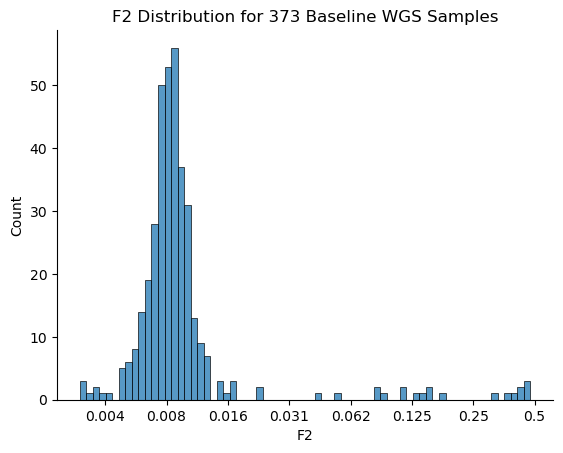

In [19]:
fig, ax = plt.subplots()

sns.histplot(data=df_trust_patients.query("pid in @final_keep_pids"),
             x='F2',
             log_scale=2,
             ax=ax
            )

rounded_ticks = [np.round(text_obj.get_position()[0], 3) for text_obj in ax.get_xticklabels()]
ax.set_xticklabels(labels=rounded_ticks)

# plt.title(f"{F2_vals_plot.SampleID.nunique()} WGS Samples across {F2_vals_plot.pid.nunique()} pids")
plt.title(f"F2 Distribution for {df_trust_patients.query('pid in @final_keep_pids').SampleID.nunique()} Baseline WGS Samples")
sns.despine()
plt.savefig("figures/F2_distribution.svg", bbox_inches='tight')

In [4]:
# to_studyto_treatment_outcome column. 
# Other descriptions in to_studyto_other_treatment_outcome
# additional comments in to_comments_treatment_outcome
treatment_outcome_dict = {1: 'cure',
                          2: 'complete',
                          3: 'defaulted', # typically they stopped taking treatment entirely, not just interruption. May have been doctor-recommended, like due to liver injury or something
                          4: 'failure',
                          5: 'extension',
                          6: 'death',
                          7: 'transferred',
                          8: 'lost_fu',
                          9: 'other'
                        }

# esp_reason_end_of_study_parti column
# Other descriptions in esp_reasonoth_end_of_study_parti
esp_dict = {1: 'complete', # completed all study requirements
            2: 'inappropriate', # should not have been included in the study
            3: 'withdrew',
            4: 'failure', # includes both groups 4 and 5 in treatment_outcome_dict, meaning the patient was culture positive at month 5 or tx was extended
            5: 'relapse',
            6: 'moved', # moved/transferred out,
            7: 'lost_fu',
            8: 'death',
            9: 'other'
            }

In [6]:
cols_lst = [
            'screen_sex',
            'screen_years',
            # 'bmi', # ordinal with 3 string groups
            'bl_bmi', # numerical BMI
            'fstrom1_baseline', # smoking yes or no
            'HIV_CD4',
            # 'bl_prevtb',
            # 'smear_grade_baseline',
            'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            # 'predicted_PLI',
            # 'predicted_Timika_Score',
            'high_lung_involvement',
            # 'peth_value_baseline',
            # 'bilateral_infiltrates',
            # 'underweight',
            # 'total_adherence',
            # 'cxr_cavity_chest_radiograph_1',
            'F2',
            'Lineage',
            # 'total_adherence',
           ]

stratify_covariates = []

# df_TCC_imputed_all = pd.read_csv(f"{data_dir}/imputed_TCC.csv")
# df_TCC_imputed_all['delayed_TCC'] = (df_TCC_imputed_all['TCC'] > 8).astype(int)

# # this subsets it down to patients who don't have NAs anywhere in the predictor data
# df_trust_patients = df_trust_patients.query("pid in @df_TCC_imputed_all.pid")

tb_deaths_only = False

# # impute cavitation. See plot below for how the threshold of 10 was determined
# Timika_PLI_difference_thresh_for_cavitation = 10

# df_trust_patients['Timika_PLI_difference'] = df_trust_patients['predicted_Timika_Score'] - df_trust_patients['predicted_PLI']
# df_trust_patients.loc[(pd.isnull(df_trust_patients['cxr_cavity_chest_radiograph_1'])) & (df_trust_patients['Timika_PLI_difference'] >= Timika_PLI_difference_thresh_for_cavitation), 'cxr_cavity_chest_radiograph_1'] = 1
# df_trust_patients.loc[(pd.isnull(df_trust_patients['cxr_cavity_chest_radiograph_1'])) & (df_trust_patients['Timika_PLI_difference'] < Timika_PLI_difference_thresh_for_cavitation), 'cxr_cavity_chest_radiograph_1'] = 0

# print(df_trust_patients['cxr_cavity_chest_radiograph_1'].value_counts(dropna=False))

df_trust_patients = df_trust_patients.query("pid in @final_keep_pids").reset_index(drop=True)
print(f"{df_trust_patients.pid.nunique()} final pids")

df_outcomes = pd.read_csv(f"{data_dir}/tx_outcomes.csv").query("pid in @final_keep_pids").reset_index(drop=True)

373 final pids


# Multivariate Models

# 0. Determine the model formulation by testing the proportional hazards assumptions

In [7]:
# df_AUC = pd.read_csv("~/TRUST_data_processing/processed_data/PK_AUC_predictions.csv")
# more_AUC = pd.read_csv("~/TRUST_data_processing/raw_data/TRUST_RIF_AUC_20250529.csv")
# more_AUC['pid'] = 'T0' + more_AUC['ID'].astype(str)
# pd.concat([df_AUC, more_AUC.rename(columns={'AUC': 'RIF_AUC'})[['pid', 'RIF_AUC']]]).to_csv("~/TRUST_data_processing/processed_data/PK_AUC_predictions.csv", index=False)

In [8]:
df_send = pd.read_csv("~/TRUST_data_processing/raw_data/TRUST_DATA_2025-05-12_1129.cleaned.wide.csv")
df_send.pid.nunique()

458

In [17]:
PK_AUC_predictions = pd.read_csv("~/TRUST_data_processing/processed_data/PK_AUC_predictions.csv")
df_send = df_send.merge(PK_AUC_predictions, on='pid', how='left')
len(df_send)

458

In [18]:
sum(pd.isnull(df_send['INH_AUC']))

3

In [19]:
df_send.loc[pd.isnull(df_send['INH_AUC'])][['pid', 'screen_years', 'screen_sex', 'bl_height', 'bl_weight', 'bl_mandrax', 'bw_cr_blood_collection_1', 'tx_bldose_treatment_outcome']].dropna(subset='tx_bldose_treatment_outcome').to_csv("addl_pids_no_AUC.csv", index=False)




In [20]:
df_send.columns[df_send.columns.str.contains('bw_cr')]

Index(['bw_cr_additional_visit2', 'bw_cr_additional_visit',
       'bw_cr_blood_collection_1', 'bw_cr_blood_collection_2',
       'bw_cr_blood_collection_3', 'bw_cr_blood_collection_4'],
      dtype='object')

In [21]:
df_send.columns[df_send.columns.str.contains('tx_bldose_treatment')]

Index(['tx_bldose_treatment_outcome'], dtype='object')

In [22]:
for col in cols_lst:
    if col in df_trust_patients:
        print(col, sum(pd.isnull(df_trust_patients[col])))

screen_sex 0
screen_years 0
bl_bmi 0
fstrom1_baseline 0
HIV_CD4 4
TTP_baseline 0
diabetes 0
F2 0
Lineage 0


In [23]:
sum(pd.isnull(df_trust_patients['RIF_AUC'])), sum(pd.isnull(df_trust_patients['RIF_AUC']))

(0, 0)

In [7]:
stratify_covariates = []

df_test_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(df_trust_patients,#.query("F2 <= 0.03"),
                                                                                                  df_pred_combined,
                                                                                                   TRUST_phenos,
                                                                                                  df_outcomes,
                                                                                                  cols_lst + ['RIF_AUC'],
                                                                                                  event_col = 'event',
                                                                                                  time_col = 'date',
                                                                                                  MIC_type='none',
                                                                                                  tb_deaths_only=tb_deaths_only,
                                                                                                 stratify_variables=stratify_covariates,
                                                                                                 binary_lineage=True
                                                                                                 )

    373 total pids


In [8]:
# no covariates violated the proportional hazards assumption
df_violating_covariates = []

for model_idx in range(len(cph_models_imputations)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_samples_imputations[model_idx], time_transform='rank').summary
    
    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)
df_violating_covariates.query("p <= 0.05")

,covariate,p,imp_num


In [9]:
df_test_results.query("pval <= 0.05").sort_values('pval')

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper
4,HIV_Low_CD4,0.303056,1.35399,0.150428,1.024902,0.508733,1,0.043945,2.786823,1.028195,7.553418


In [10]:
df_test_results.covariate.unique()

array(['F2', 'RIF_AUC', 'TTP_baseline', 'high_lung_involvement',
       'HIV_Low_CD4', 'HIV_High_CD4', 'bl_bmi', 'diabetes',
       'fstrom1_baseline', 'screen_sex', 'Lineage_2',
       'smear_pos_no_contam_sputum_specimen_1', 'screen_years'],
      dtype=object)

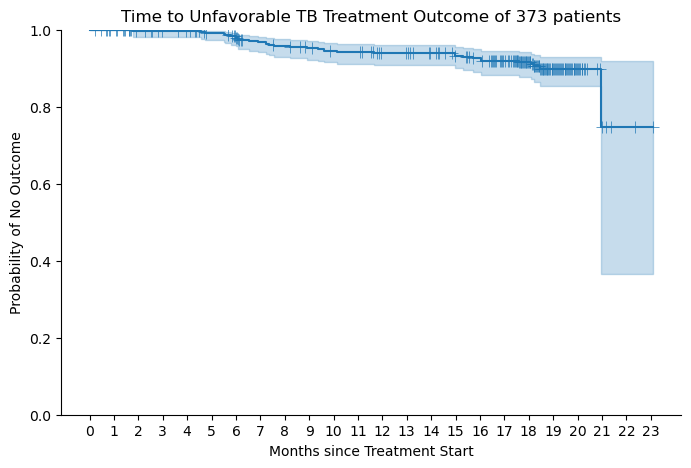

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

df_outcomes = df_outcomes.query("pid in @df_trust_patients.pid")

if tb_deaths_only:
    df_outcomes.loc[(df_outcomes["TB_death"]==0) & (df_outcomes["event"]==1), "event"] = 0

kmf_full = lifelines.KaplanMeierFitter()
kmf_full.fit(df_outcomes['months'], event_observed=df_outcomes['event'])
# print(kmf_full.median_survival_time_)
kmf_full.plot_survival_function(show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5})
# plt.ylim(0, 1)

# Set x-axis ticks to show all integers
# ax.set_xticks(range(0, df_outcomes['weeks'].max() + 1))

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_outcomes.pid.nunique()} patients")
plt.ylabel("Probability of No Outcome") #
plt.xlabel("Months since Treatment Start")


plt.ylim(0, 1)

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_outcomes['months'].max()) + 1))

plt.gca().get_legend().remove()

sns.despine()
# plt.savefig("figures/outcomes/KM_curve.svg", bbox_inches='tight')

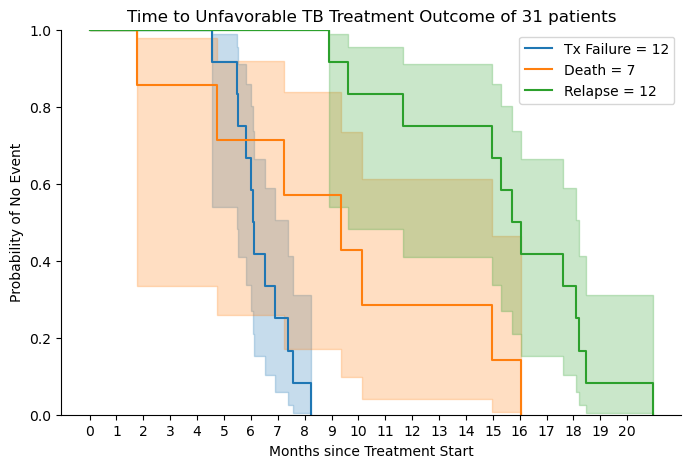

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

kmf = lifelines.KaplanMeierFitter()

stratify_col = 'event_type'

color_dict = dict(zip(['tx_failure', 'death', 'relapse'], sns.color_palette('tab10')))
labels_dict = {'tx_failure': 'Tx Failure', 'death': 'Death', 'relapse': 'Relapse'}

for group in ['tx_failure', 'death', 'relapse']:

    df_single_group = df_outcomes.query(f"{stratify_col}==@group")

    # exclude non-TB deaths that would be censored
    if tb_deaths_only:
        df_single_group = df_single_group.query("event==1 & ~(TB_death==0 & event==1)")
    else:
        df_single_group = df_single_group.query("event==1")
    
    if group != 'cure':
        kmf.fit(df_single_group['months'], event_observed=df_single_group['event'], label=group)
        kmf.plot_survival_function(ax=ax, color=color_dict[group], show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{labels_dict[group]} = {len(df_single_group)}")

if tb_deaths_only:
    num_poor_event = df_outcomes.query(f"event==1 & ~(TB_death==0 & event==1)").pid.nunique()# & pid in @df_samples.pid").pid.nunique()
else:
    num_poor_event = df_outcomes.event.sum()
    
plt.title(f"Time to Unfavorable TB Treatment Outcome of {num_poor_event} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.ylim(0, 1)

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_outcomes.query(f"event == 1")['months'].max()) + 1))

sns.despine()
# plt.show()
# plt.savefig("./figures/outcomes/KM_curve_events.svg", bbox_inches='tight')

In [27]:
df_outcomes.event.value_counts()

event
0    346
1     27
Name: count, dtype: int64

In [28]:
df_outcomes.event.mean()

0.07238605898123325

In [14]:
df_outcomes.query("event==1").event_type.value_counts()

event_type
tx_failure    12
relapse       12
death          7
Name: count, dtype: int64

In [15]:
df_outcomes.query("event_type != 'cure'").event_type.value_counts()

event_type
relapse       21
death         14
tx_failure    12
Name: count, dtype: int64

In [13]:
df_outcomes.query("event_type == 'death'").TB_death.value_counts()

TB_death
1.0    9
0.0    5
Name: count, dtype: int64

(array([ 22.,   8.,  18.,  11.,   7.,  21., 227.,  42.,   3.,   2.]),
 array([  7. ,  89.8, 172.6, 255.4, 338.2, 421. , 503.8, 586.6, 669.4,
        752.2, 835. ]),
 <BarContainer object of 10 artists>)

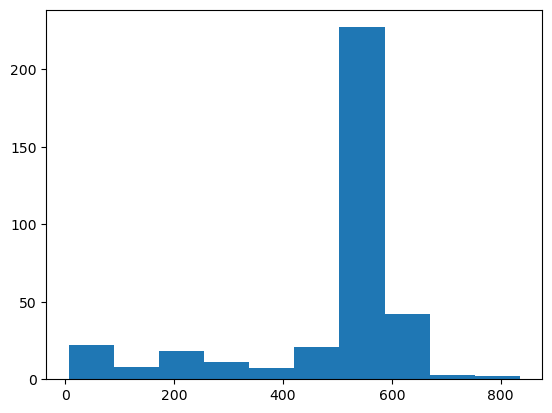

In [32]:
plt.hist(df_outcomes['time_in_trial'])

In [33]:
df_outcomes['time_in_trial'].max(), df_outcomes['time_in_trial'].median()

(835.0, 545.0)

In [34]:
545/365, 835/365

(1.4931506849315068, 2.287671232876712)

In [139]:
df_outcomes.pid.nunique()

373

In [154]:
df_trust_patients.pid.nunique()

373

In [158]:
TRUST_phenos.dropna(subset='PZA_lower_bound').merge(df_trust_patients)

,pid,RIF_lower_bound,RIF_upper_bound,RIF_midpoint,INH_lower_bound,INH_upper_bound,INH_midpoint,EMB_lower_bound,EMB_upper_bound,EMB_midpoint,...,PZA_AUC,EMB_AUC,View,Outlier,predicted_PLI,predicted_Timika_Score,unique_patient,Date_of_Death,mixed_infect,L1_L3
0,T0020,0.06,0.125,0.0925,0.0125,0.025,0.01875,0.00,0.60,0.300,...,233.26,11.720,1B,0.0,28.476437,37.277225,13,NaN,0.0,1.0
1,T0040,0.06,0.125,0.0925,0.0250,0.050,0.03750,0.00,0.60,0.300,...,313.82,14.462,1B,0.0,14.504039,19.507260,14,NaN,0.0,0.0
2,T0043,0.06,0.125,0.0925,0.0250,0.050,0.03750,0.00,0.60,0.300,...,342.63,16.209,1B,1.0,33.596860,47.150955,16,NaN,0.0,0.0
3,T0051,0.06,0.125,0.0925,0.0500,0.100,0.07500,0.00,0.60,0.300,...,350.09,10.734,1B,0.0,11.959009,11.885069,18,2019-06-05,0.0,0.0
4,T0065,0.03,0.060,0.0450,0.0250,0.050,0.03750,0.00,0.60,0.300,...,289.94,10.141,1B,0.0,21.468224,29.287943,19,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,T0253,0.03,0.060,0.0450,0.0500,0.100,0.07500,0.60,1.25,0.925,...,292.73,19.444,1B,0.0,21.486970,30.842240,404,NaN,0.0,0.0
258,T0287,0.06,0.125,0.0925,0.0250,0.050,0.03750,0.60,1.25,0.925,...,366.41,23.866,1B,0.0,29.649431,31.317760,405,NaN,0.0,0.0
259,T0297,0.03,0.060,0.0450,0.0250,0.050,0.03750,1.25,2.50,1.875,...,274.51,16.901,1B,0.0,26.433937,31.465454,406,NaN,0.0,0.0
260,T0290,0.03,0.060,0.0450,0.0250,0.050,0.03750,1.25,2.50,1.875,...,274.13,17.737,1B,0.0,12.186201,16.158964,12,NaN,0.0,0.0


## 2. Add MICs individually to the final model

In [18]:
exclude_resistance_lst = [0]
MIC_type_lst = ['measured', 'predicted']
tb_deaths_only_lst = [tb_deaths_only]

param_grid = list(itertools.product(exclude_resistance_lst, MIC_type_lst, tb_deaths_only_lst, drugs_lst + [drugs_lst] + [['RIF', 'INH', 'EMB']]))
# param_grid = list(itertools.product(exclude_resistance_lst, MIC_type_lst, tb_deaths_only_lst, drugs_lst + [drugs_lst]))

# If you prefer the result as a list of dictionaries (one for each combination):
param_grid_dicts = [
    {
     'exclude_resistance': exclude_resistance,
     'MIC_type': MIC_type,
     'tb_deaths_only': tb_deaths_only,
     'include_drugs_lst': [drug] if type(drug) != list else drug # try each drug individuallly and also all of them together
    }
    for exclude_resistance, MIC_type, tb_deaths_only, drug in param_grid
]

len(param_grid_dicts)

12

In [19]:
df_outcomes_model_final = []

for i, params_lst in enumerate(param_grid_dicts):

    print(f"Model {i+1}")

    # skip cases where MIC = measured and PZA is included because it drops the sample size
    if params_lst['MIC_type'] == 'measured' and 'PZA' in params_lst['include_drugs_lst']:
        print("    Skipping model")

    else:
        # only include drug AUCs if the MIC is included
        drug_AUC_lst = [f"{drug}_AUC" for drug in params_lst['include_drugs_lst']]
        print(f"    {drug_AUC_lst}")
        
        # because the RIF pred MIC range is so small, and the values only differ at the ends (the middle of the distribution is essentially the same),
        # it can lead to unstable estimated hazard ratios. So better to binarize it at the median
        if 'RIF' in params_lst['include_drugs_lst'] and params_lst['MIC_type'] == 'predicted':
            binarize_drugs = ['RIF']
        else:
            binarize_drugs = []
                    
        df_model_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(df_trust_patients,
                                                                                                          df_pred_combined,
                                                                                                          TRUST_phenos,
                                                                                                          df_outcomes,
                                                                                                          cols_lst + drug_AUC_lst,
                                                                                                          event_col = 'event',
                                                                                                          time_col = 'date',
                                                                                                          exclude_resistance=params_lst['exclude_resistance'],
                                                                                                          MIC_type=params_lst['MIC_type'],
                                                                                                          tb_deaths_only=params_lst['tb_deaths_only'],
                                                                                                          include_drugs=params_lst['include_drugs_lst'],
                                                                                                          binarize_drugs = binarize_drugs,#params_lst['include_drugs_lst'],
                                                                                                          interact_MIC_lineage=False,
                                                                                                          invert_OR=False,
                                                                                                          stratify_variables=stratify_covariates,
                                                                                                          binary_lineage=True,
                                                                                                         )

        for model_idx in range(len(cph_models_imputations)):

            df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_samples_imputations[model_idx], time_transform='rank').summary.reset_index().rename(columns={'index': 'covariate'})
        
            violating_covariates = df_proportional_hazards.query("p <= 0.01").covariate.values

            if len(violating_covariates) > 0:
                print(f"Predictors {violating_covariates} violated the proportional hazards assumptions")

        predictors_lst = df_model_results.covariate.values
    
        df_model_results['exclude_resistance'] = params_lst['exclude_resistance']
        df_model_results['MIC_type'] = params_lst['MIC_type']
        df_model_results['tb_deaths_only'] = params_lst['tb_deaths_only']
        df_model_results['include_drugs'] = ','.join(params_lst['include_drugs_lst'])
        df_model_results['num_pids'] = df_samples_imputations[0]['pid'].nunique()
        
        df_outcomes_model_final.append(df_model_results)

df_outcomes_model_final = pd.concat(df_outcomes_model_final)

# annotate significance
df_outcomes_model_final.loc[(df_outcomes_model_final["pval"] <= 0.05), 'significant'] = 1
# df_outcomes_model_final.to_csv("./model_results/outcomes/TB_deaths_only.csv", index=False)
df_outcomes_model_final.to_csv("./model_results/outcomes/all_deaths.csv", index=False)

Model 1
    ['RIF_AUC']
    372 total pids
Model 2
    ['INH_AUC']
    372 total pids
Model 3
    ['EMB_AUC']
    371 total pids
Model 4
    Skipping model
Model 5
    Skipping model
Model 6
    ['RIF_AUC', 'INH_AUC', 'EMB_AUC']
    371 total pids
Model 7
    ['RIF_AUC']
Binarized RIF_pred_MIC at 0.05999996 µg/mL, 36.7% are high
    373 total pids
Model 8
    ['INH_AUC']
    373 total pids
Model 9
    ['EMB_AUC']
    372 total pids
Model 10
    ['PZA_AUC']
    373 total pids
Model 11
    ['RIF_AUC', 'INH_AUC', 'EMB_AUC', 'PZA_AUC']
Binarized RIF_pred_MIC at 0.05999996 µg/mL, 36.7% are high
    372 total pids
Predictors ['EMB_AUC'] violated the proportional hazards assumptions
Model 12
    ['RIF_AUC', 'INH_AUC', 'EMB_AUC']
Binarized RIF_pred_MIC at 0.05999996 µg/mL, 36.7% are high
    372 total pids


In [21]:
df_outcomes_model_final = pd.read_csv("./model_results/outcomes/TB_deaths_only.csv")
# df_outcomes_model_final = pd.read_csv("./model_results/outcomes/all_deaths.csv")

print('Measured MIC Associations:', df_outcomes_model_final.query("MIC_type=='measured' & pval <= 0.05").covariate.unique())
print('Predicted MIC Associations:', df_outcomes_model_final.query("MIC_type=='predicted' & pval <= 0.05").covariate.unique())

OR_col = 'OR'

# transform some hazard ratios for interpretability
# 1. Age: make it for each decade
# 2. RIF AUC: by 10. It ranges from 0 - 120, but mostly 0-70. Nah, the confidence interval looks weird.
# 3: % lung involvement: by 10 also. Ranges from 0-80. Nah, makes it huge. Stick to 1%

for col in ['screen_years']:# + list(df_TCC_model_final.query("covariate.str.endswith('_AUC')").covariate.unique()):#, 'RIF_AUC']:
    df_outcomes_model_final.loc[df_outcomes_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_outcomes_model_final.loc[df_outcomes_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

    
# MIC HRs should be transformed to per 0.01 µg/mL for RIF, INH, and EMB and per 10 µg/mL for PZA  
# transform the confidence intervals for the predicted MICs to per 0.01, as they did in the NEJM paper
for col in df_outcomes_model_final.query("covariate.str.endswith('_midpoint') | covariate.str.endswith('_pred_MIC')").covariate.unique():

    multiply_factor = 0.1
        
    print(col, multiply_factor)
    
    df_outcomes_model_final.loc[df_outcomes_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_outcomes_model_final.loc[df_outcomes_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**multiply_factor

Measured MIC Associations: ['HIV_Low_CD4']
Predicted MIC Associations: ['HIV_Low_CD4' 'RIF_pred_MIC_high' 'Lineage_2']
RIF_midpoint 0.1
INH_midpoint 0.1
EMB_midpoint 0.1
INH_pred_MIC 0.1
EMB_pred_MIC 0.1
PZA_pred_MIC 0.1


In [22]:
# df_outcomes_model_final = pd.read_csv("./model_results/outcomes/TB_deaths_only.csv")
df_outcomes_model_final = pd.read_csv("./model_results/outcomes/all_deaths.csv")

print('Measured MIC Associations:', df_outcomes_model_final.query("MIC_type=='measured' & pval <= 0.05").covariate.unique())
print('Predicted MIC Associations:', df_outcomes_model_final.query("MIC_type=='predicted' & pval <= 0.05").covariate.unique())

OR_col = 'OR'

# transform some hazard ratios for interpretability
# 1. Age: make it for each decade
# 2. RIF AUC: by 10. It ranges from 0 - 120, but mostly 0-70. Nah, the confidence interval looks weird.
# 3: % lung involvement: by 10 also. Ranges from 0-80. Nah, makes it huge. Stick to 1%

for col in ['screen_years']:# + list(df_TCC_model_final.query("covariate.str.endswith('_AUC')").covariate.unique()):#, 'RIF_AUC']:
    df_outcomes_model_final.loc[df_outcomes_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_outcomes_model_final.loc[df_outcomes_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

    
# MIC HRs should be transformed to per 0.01 µg/mL for RIF, INH, and EMB and per 10 µg/mL for PZA  
# transform the confidence intervals for the predicted MICs to per 0.01, as they did in the NEJM paper
for col in df_outcomes_model_final.query("covariate.str.endswith('_midpoint') | covariate.str.endswith('_pred_MIC')").covariate.unique():

    multiply_factor = 0.1
        
    print(col, multiply_factor)
    
    df_outcomes_model_final.loc[df_outcomes_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_outcomes_model_final.loc[df_outcomes_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**multiply_factor

Measured MIC Associations: ['HIV_Low_CD4']
Predicted MIC Associations: ['RIF_pred_MIC_high' 'HIV_Low_CD4' 'diabetes']
RIF_midpoint 0.1
INH_midpoint 0.1
EMB_midpoint 0.1
INH_pred_MIC 0.1
EMB_pred_MIC 0.1
PZA_pred_MIC 0.1


In [25]:
df_outcomes_model_final.query("pval <= 0.05")[['covariate', 'OR']]

,covariate,OR
5,HIV_Low_CD4,2.800335
18,HIV_Low_CD4,2.932565
33,HIV_Low_CD4,2.942013
63,RIF_pred_MIC_high,4.075872
65,HIV_Low_CD4,2.869692
68,diabetes,3.916492
77,HIV_Low_CD4,2.931330
93,HIV_Low_CD4,3.045497
120,RIF_pred_MIC_high,5.437224
140,RIF_pred_MIC_high,4.583431


In [26]:
df_outcomes_model_final.query("covariate=='Lineage_2'")

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper,exclude_resistance,MIC_type,tb_deaths_only,include_drugs,num_pids,significant
11,Lineage_2,0.069909,1.072410,0.187683,0.139632,0.374867,1,0.709533,1.149850,0.551511,2.397335,0,measured,False,RIF,372,NaN
24,Lineage_2,0.076642,1.079655,0.185938,0.153080,0.371381,1,0.680199,1.165418,0.562810,2.413247,0,measured,False,INH,372,NaN
39,Lineage_2,0.047062,1.048187,0.194325,0.093998,0.388128,1,0.808639,1.098557,0.513390,2.350703,0,measured,False,EMB,371,NaN
56,Lineage_2,0.037050,1.037745,0.198893,0.074000,0.397251,1,0.852225,1.076807,0.494307,2.345732,0,measured,False,"RIF,INH,EMB",371,NaN
71,Lineage_2,0.600043,1.822197,0.330972,1.198515,0.661077,1,0.069836,3.315191,0.907401,12.112060,0,predicted,False,RIF,373,NaN
84,Lineage_2,0.070531,1.073078,0.185916,0.140877,0.371345,1,0.704414,1.151283,0.556023,2.383809,0,predicted,False,INH,373,NaN
99,Lineage_2,0.074873,1.077747,0.188220,0.149546,0.375939,1,0.690782,1.161307,0.555837,2.426312,0,predicted,False,EMB,372,NaN
113,Lineage_2,0.077773,1.080878,0.185944,0.155343,0.371401,1,0.675755,1.168059,0.564063,2.418809,0,predicted,False,PZA,373,NaN
132,Lineage_2,0.660546,1.935848,0.343725,1.319334,0.686535,1,0.054640,3.740928,0.974090,14.366778,0,predicted,False,"RIF,INH,EMB,PZA",372,NaN
150,Lineage_2,0.617905,1.855038,0.336830,1.234166,0.672764,1,0.066584,3.435512,0.919039,12.842483,0,predicted,False,"RIF,INH,EMB",372,NaN


In [51]:
labels_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Male Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity at Baseline',
              'diabetes': 'Diabetes',
              'Lineage_1': 'Lineage 1',
              'Lineage_2': 'Lineage 2',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'RIF_pred_MIC': 'Predicted RIF MIC',
              'INH_pred_MIC': 'Predicted INH MIC',
              'EMB_pred_MIC': 'Predicted EMB MIC',
              'PZA_pred_MIC': 'Predicted PZA MIC',
              'RIF_midpoint': 'Measured RIF MIC',
              'INH_midpoint': 'Measured INH MIC',
              'EMB_midpoint': 'Measured EMB MIC',
              'PZA_midpoint': 'Measured PZA MIC',
               'delayed_TCC': 'TCC > 8 Weeks',
               'TTP_baseline': 'TTP at Baseline',
               'peth_value_baseline': 'PEth',
               'fstrom1_baseline': 'Smoking',
               'RIF_pred_MIC_high': 'Predicted RIF MIC > 0.06 µg/mL',
               # 'INH_pred_MIC_high': 'Predicted Isoniazid MIC',
               'PZA_pred_MIC_high': 'Predicted Pyrazinamide MIC > 24.6 µg/mL',
               'HIV_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$', # when we computed the relative risk, it was this group vs. the other two groups,
               'high_lung_involvement': 'PLI > 20%',
               'Not_Lineage_2': 'Not Lineage 2'
             }

In [56]:
drug_covariates = ['RIF_midpoint', 'RIF_pred_MIC_high', 'RIF_pred_MIC', 'RIF_AUC', 'INH_midpoint', 'INH_pred_MIC', 'INH_AUC', 'EMB_midpoint', 'EMB_pred_MIC', 'EMB_AUC', 'PZA_midpoint', 'PZA_pred_MIC', 'PZA_AUC']

microbiological_covariates = ['smear_pos_no_contam_sputum_specimen_1', 'TTP_baseline', 'high_lung_involvement', 'Lineage_2', 'F2']

demographic_covariates = ['screen_sex', 'screen_years', 'bl_bmi', 'HIV_High_CD4', 'HIV_Low_CD4', 'diabetes', 'fstrom1_baseline']

covariate_groups_lst = [drug_covariates, microbiological_covariates, demographic_covariates]

figure_names = ['forest_plot_predicted_MIC', 'forest_plot_microbiological', 'forest_plot_demographics']

In [57]:
for i, group in enumerate(covariate_groups_lst):
    
    forest_plot(df_outcomes_model_final.query("MIC_type=='predicted' & include_drugs=='RIF,INH,EMB,PZA'"), 
                group, 
                labels_dict, 
                val_col='OR', 
                alpha=0.05,
                log=True,
                pval_offset=10,
                saveName=f"./figures/outcomes/{figure_names[i]}.svg",
               )
    
forest_plot(df_outcomes_model_final.query("MIC_type=='measured' & include_drugs=='RIF,INH,EMB'"), 
            drug_covariates, 
            labels_dict, 
            val_col='OR', 
            alpha=0.05, 
            log=False,
            pval_offset=1.01,
            saveName="./figures/outcomes/forest_plot_measured_MIC.svg"
           )

RIF_pred_MIC_high: p = 0.16322639398653757


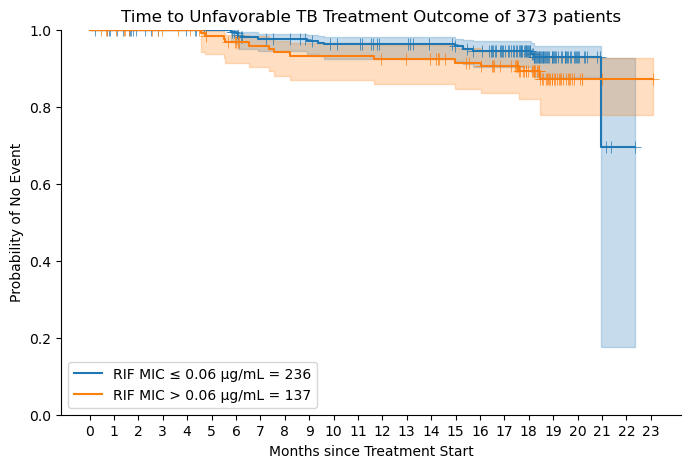

In [167]:
fig, ax = plt.subplots(figsize=(8, 5))

kmf = lifelines.KaplanMeierFitter()

stratify_col = 'RIF_pred_MIC_high'
color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

# color_dict = dict(zip(['tx_failure', 'death', 'relapse'], sns.color_palette('tab10')))
# labels_dict = {'tx_failure': 'Tx Failure', 'death': 'Death', 'relapse': 'Relapse'}

if tb_deaths_only:
    df_test.loc[df_test['TB_death']==0, 'event'] = 0

for group in np.sort(df_test[stratify_col].unique()):
    
    # for event_type in list(set(df_test.event_type.unique()) - set(['cure'])):

        # df_single_group = df_test.query(f"{stratify_col}==@group & event_type==@event_type")
        
        # group_name = f"{event_type}_{group}"
        
    df_single_group = df_test.query(f"{stratify_col}==@group")
    group_name = {0: 'RIF MIC ≤ 0.06 µg/mL', 1: 'RIF MIC > 0.06 µg/mL'}[group]

    kmf.fit(df_single_group['months'], event_observed=df_single_group['event'], label=group_name)
    kmf.plot_survival_function(ax=ax, show_censors=True, color=color_dict[group], censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{group_name} = {len(df_single_group)}")

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_test.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.ylim(0, 1)

logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_test.query(f"{stratify_col}==1")['date'], 
                                                                  durations_B=df_test.query(f"{stratify_col}==0")['date'], 
                                                                  event_observed_A=df_test.query(f"{stratify_col}==1")['event'], 
                                                                  event_observed_B=df_test.query(f"{stratify_col}==0")['event'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )

print(f"{stratify_col}: p = {logRank_test_results.p_value}")

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_test['months'].max()) + 1))

sns.despine()
# plt.show()
plt.savefig("./figures/outcomes/KM_curve_RIF_pred_MIC_binarized.svg", bbox_inches='tight')

In [74]:
df_test[['RIF_pred_MIC', 'PZA_pred_MIC']].corr()

,RIF_pred_MIC,PZA_pred_MIC
RIF_pred_MIC,1.000000,0.179565
PZA_pred_MIC,0.179565,1.000000


In [117]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# X = add_constant(df_test[['RIF_pred_MIC_high', 'PZA_pred_MIC', 'Lineage']])
df_VIF = df_test[['RIF_pred_MIC_high', 'RIF_pred_MIC', 'PZA_pred_MIC', 'Lineage']]
df_VIF['PZA_pred_MIC'] = np.log2(df_VIF['PZA_pred_MIC'])
df_VIF['RIF_pred_MIC'] = np.log2(df_VIF['RIF_pred_MIC'])

df_dummies = pd.get_dummies(df_test['Lineage'], prefix='Lineage').astype(int)
df_VIF = pd.concat([df_VIF, df_dummies], axis=1)
# del df_VIF['Lineage']
# del df_VIF['Lineage_2']

X = add_constant(df_VIF[['Lineage_4', 'RIF_pred_MIC_high', 'PZA_pred_MIC']])

pd.Series([variance_inflation_factor(X.values, i) 
               for i in range(X.shape[1])], 
              index=X.columns)

const                286.929420
Lineage_4              1.492129
RIF_pred_MIC_high      1.398705
PZA_pred_MIC           1.150232
dtype: float64

In [119]:
df_VIF[['RIF_pred_MIC_high', 'PZA_pred_MIC', 'Lineage_4']].corr()

,RIF_pred_MIC_high,PZA_pred_MIC,Lineage_4
RIF_pred_MIC_high,1.000000,-0.087585,0.484816
PZA_pred_MIC,-0.087585,1.000000,0.264201
Lineage_4,0.484816,0.264201,1.000000


In [96]:
df_test['PZA_pred_MIC']

0      26.149433
1      26.149433
2      13.725444
3      24.936594
4      16.532278
         ...    
343    26.149433
344    24.936594
345    26.149433
346    24.147413
347    13.725444
Name: PZA_pred_MIC, Length: 348, dtype: float64

In [94]:
[variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

[42.648651003050844,
 1.5567894268007518,
 1.0302552243612466,
 1.5571840652401578]

In [90]:
X.shape[1]

4

In [91]:
X.columns

Index(['const', 'RIF_pred_MIC_high', 'PZA_pred_MIC', 'Lineage'], dtype='object')

In [80]:
X

,const,RIF_pred_MIC,PZA_pred_MIC,Lineage
0,1.0,0.058450,26.149433,2
1,1.0,0.058450,26.149433,2
2,1.0,0.059444,13.725444,3
3,1.0,0.062895,24.936594,4
4,1.0,0.058450,16.532278,2
...,...,...,...,...
343,1.0,0.058450,26.149433,2
344,1.0,0.060898,24.936594,4
345,1.0,0.058450,26.149433,2
346,1.0,0.057091,24.147413,4


In [23]:
df_test.groupby('RIF_pred_MIC_high')['PZA_pred_MIC'].mean()

RIF_pred_MIC_high
0    23.604627
1    22.956203
Name: PZA_pred_MIC, dtype: float64

In [289]:
df_test[['RIF_pred_MIC_high', 'event']].value_counts()

RIF_pred_MIC_high  event
0                  0        208
1                  0        113
0                  1         14
1                  1         13
Name: count, dtype: int64

In [332]:
pd.DataFrame(df_test.query("event==1")[['RIF_pred_MIC_high', 'event_type']].value_counts()).sort_values(['event_type', 'RIF_pred_MIC_high'])

,,count
RIF_pred_MIC_high,event_type,
0,death,2
1,death,1
0,relapse,7
1,relapse,5
0,tx_failure,5
1,tx_failure,7


In [255]:
df_test['Lineage'].value_counts()

Lineage
2    174
4    153
3     21
Name: count, dtype: int64

In [274]:
# df_cxr_predictions = df_test[['pid', 'predicted_PLI', 'predicted_Timika_Score', 'cxr_cavity_chest_radiograph_1']]
# df_cxr_predictions['Difference'] = df_cxr_predictions['predicted_Timika_Score'] - df_cxr_predictions['predicted_PLI']

# sns.histplot(data=df_cxr_predictions.melt(id_vars='pid'),
#              x='value',
#              hue='variable',
#              multiple='dodge',
#              # common_norm=False,
#             )

# plt.xlabel('Predicted Value')
# # plt.legend(title='')
# sns.despine()
# plt.show()

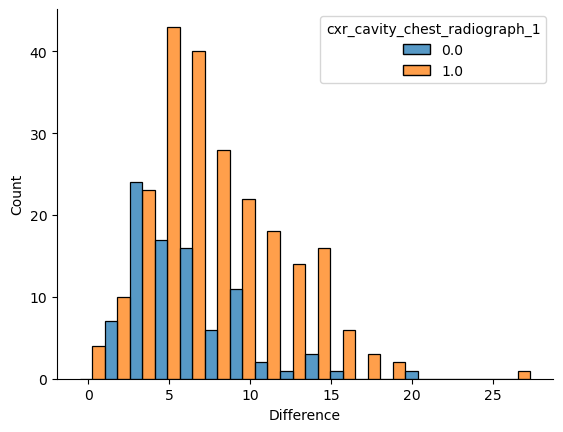

In [276]:
sns.histplot(data=df_cxr_predictions,
             x='Difference',
             hue='cxr_cavity_chest_radiograph_1',
             multiple='dodge',
             common_norm=False,
            )

# plt.xlabel('Difference')
# plt.legend(title='')
sns.despine()
plt.show()

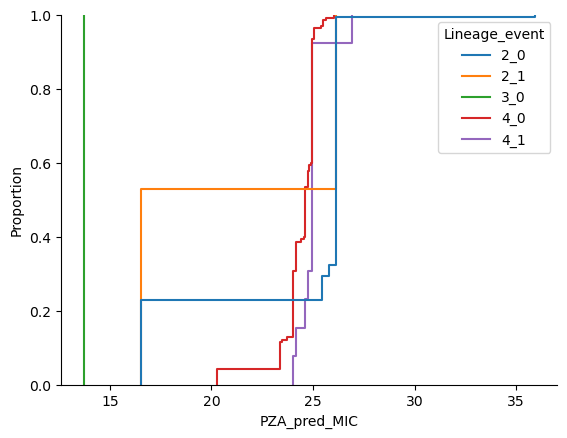

In [26]:
sns.ecdfplot(data=df_test.sort_values('Lineage_event'),
             x='PZA_pred_MIC',
             hue='Lineage_event',
             # palette = {1: "#DF83AC", 2: "#7098CB", 3: "#815D9F", 4: "#E76956"}
            )

sns.despine()
plt.show()

In [135]:
df_test.groupby('event')['RIF_pred_MIC'].mean()

event
0    0.058378
1    0.060722
Name: RIF_pred_MIC, dtype: float64

In [43]:
# transform some hazard ratios for interpretability
# # 1. F2: by 0.5, which is the full range?
# df_outcomes_model_final.loc[df_outcomes_model_final['covariate']=='F2', ['OR', 'OR_lower', 'OR_upper']] = df_outcomes_model_final.loc[df_outcomes_model_final['covariate']=='F2', ['OR', 'OR_lower', 'OR_upper']]**0.5

OR_col = 'OR'

# # 2. Adherence rate: by 0.1
# df_outcomes_model_final.loc[df_outcomes_model_final['covariate']=='adherence_rate', ['OR', 'OR_lower', 'OR_upper']] = df_outcomes_model_final.loc[df_outcomes_model_final['covariate']=='adherence_rate', ['OR', 'OR_lower', 'OR_upper']]**0.1

# MIC HRs should be transformed to per 0.01 µg/mL for RIF, INH, and EMB and per 10 µg/mL for PZA  
# transform the confidence intervals for the predicted MICs to per 0.01, as they did in the NEJM paper
df_outcomes_model_final = pd.read_csv("./model_results/outcomes/TB_deaths_only.csv")

for col in ['screen_years']:# + list(df_outcomes_model_final.query("covariate.str.endswith('_AUC')").covariate.unique()):#, 'RIF_AUC']:
    
    df_outcomes_model_final.loc[df_outcomes_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_outcomes_model_final.loc[df_outcomes_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

for col in np.concatenate([df_outcomes_model_final.query("covariate.str.endswith('_midpoint') | covariate.str.endswith('_pred_MIC')").covariate.unique(), np.array(['F2'])]):

    if col == 'F2':
        multiply_factor = 0.5
    else:
        multiply_factor = 0.1

    print(col, multiply_factor)
    
    df_outcomes_model_final.loc[df_outcomes_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_outcomes_model_final.loc[df_outcomes_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**multiply_factor

RIF_midpoint 0.1
INH_midpoint 0.1
EMB_midpoint 0.1
INH_pred_MIC 0.1
EMB_pred_MIC 0.1
PZA_pred_MIC 0.1
F2 0.5


In [44]:
drug_covariates = ['RIF_midpoint', 'RIF_pred_MIC_high', 'RIF_pred_MIC', 'RIF_AUC', 'INH_midpoint', 'INH_pred_MIC', 'INH_AUC', 'EMB_midpoint', 'EMB_pred_MIC', 'EMB_AUC', 'PZA_midpoint', 'PZA_pred_MIC', 'PZA_AUC']

microbiological_covariates = ['TTP_baseline', 'high_lung_involvement', 'Not_Lineage_2', 'F2']

demographic_covariates = ['screen_sex', 'screen_years', 'diabetes', 'bl_bmi', 'fstrom1_baseline', 'HIV_High_CD4', 'HIV_Low_CD4', 'HIV_CD4']

covariate_groups_lst = [drug_covariates, microbiological_covariates, demographic_covariates]

figure_names = ['forest_plot_predicted_MIC', 'forest_plot_microbiological', 'forest_plot_demographics']

In [47]:
labels_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Male Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity at Baseline',
              'diabetes': 'Diabetes',
              'Lineage_1': 'Lineage 1',
              'Lineage_2': 'Lineage 2',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'RIF_pred_MIC': 'Predicted RIF MIC',
              'INH_pred_MIC': 'Predicted INH MIC',
              'EMB_pred_MIC': 'Predicted EMB MIC',
              'PZA_pred_MIC': 'Predicted PZA MIC',
              'RIF_midpoint': 'Measured RIF MIC',
              'INH_midpoint': 'Measured INH MIC',
              'EMB_midpoint': 'Measured EMB MIC',
              'PZA_midpoint': 'Measured PZA MIC',
               'delayed_TCC': 'TCC > 8 Weeks',
               'TTP_baseline': 'TTP at Baseline',
               'peth_value_baseline': 'PEth',
               'fstrom1_baseline': 'Smoking',
               'RIF_pred_MIC_high': 'Predicted RIF MIC > 0.06 µg/mL',
               # 'INH_pred_MIC_high': 'Predicted Isoniazid MIC',
               'PZA_pred_MIC_high': 'Predicted Pyrazinamide MIC > 24.6 µg/mL',
               'HIV_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$', # when we computed the relative risk, it was this group vs. the other two groups,
               'high_lung_involvement': 'PLI > 20%',
               'Not_Lineage_2': 'Not Lineage 2'
             }

In [ ]:
for i, group in enumerate(covariate_groups_lst):
    
    forest_plot(df_outcomes_model_final.query("MIC_type=='predicted' & include_drugs=='RIF,INH,EMB,PZA'"), 
                group, 
                labels_dict, 
                val_col='OR', 
                alpha=0.05,
                log=True,
                saveName=f"./figures/outcomes/{figure_names[i]}.svg",
               )
    
forest_plot(df_outcomes_model_final.query("MIC_type=='measured' & include_drugs=='RIF,INH,EMB'"), 
            drug_covariates, 
            labels_dict, 
            val_col='OR', 
            alpha=0.05,
            log=True,
            saveName="./figures/outcomes/forest_plot_measured_MIC.svg"
           )

# Binarize MICs to compare fit between MICs and binary resistance variable

Other drugs have little to no resistance, so difficult to interpret

In [29]:
def compare_binary_continuous_resistance_models(drug, final_patient_predictors, MIC_type, include_no_MIC_model=True):

    # must be testing MICs in this function
    assert MIC_type in ['predicted', 'measured']

    # model with binary resistance
    df_model_results_binary, _, cph_models_imputation_binary = fit_cox_models_all_imputations(df_trust_patients,
                                                                          df_pred_combined,
                                                                           TRUST_phenos,
                                                                          df_imputed,
                                                                          df_outcomes,
                                                                          final_patient_predictors,
                                                                          event_col = 'event',
                                                                          time_col = 'date',
                                                                          exclude_resistance=0,
                                                                          MIC_type=MIC_type,
                                                                          binarize_MICs=True,
                                                                          tb_deaths_only=True,
                                                                          include_drugs=[drug],
                                                                          invert_OR=False,
                                                                          include_interactions=False,
                                                                          penalize_model=False,
                                                                          original_dataset_only=False,
                                                                          # cluster_col='household_num'
                                                                         )

    # model with MIC
    df_model_results, _, cph_models_imputation = fit_cox_models_all_imputations(df_trust_patients,
                                                                  df_pred_combined,
                                                                   TRUST_phenos,
                                                                  df_imputed,
                                                                  df_outcomes,
                                                                  final_patient_predictors,
                                                                  event_col = 'event',
                                                                  time_col = 'date',
                                                                  exclude_resistance=0,
                                                                  MIC_type=MIC_type,
                                                                  binarize_MICs=False,
                                                                  tb_deaths_only=True,
                                                                  include_drugs=[drug],
                                                                  invert_OR=False,
                                                                  include_interactions=False,
                                                                  penalize_model=False,
                                                                  original_dataset_only=False,
                                                                  # cluster_col='household_num'
                                                                 )

    # model without resistance
    if include_no_MIC_model:
        
        df_model_results_no_resistance, _, cph_models_imputation_no_resistance = fit_cox_models_all_imputations(df_trust_patients,
                                                                                  df_pred_combined,
                                                                                   TRUST_phenos,
                                                                                  df_imputed,
                                                                                  df_outcomes,
                                                                              final_patient_predictors,
                                                                              event_col = 'event',
                                                                              time_col = 'date',
                                                                              exclude_resistance=0,
                                                                              MIC_type='none',
                                                                              binarize_MICs=False,
                                                                              tb_deaths_only=True,
                                                                              include_drugs=[drug],
                                                                              invert_OR=False,
                                                                              include_interactions=False,
                                                                              penalize_model=False,
                                                                              original_dataset_only=False,
                                                                              # cluster_col='household_num'
                                                                             )

        return cph_models_imputation_no_resistance, cph_models_imputation, cph_models_imputation_binary, df_model_results_no_resistance, df_model_results, df_model_results_binary

    else:
        return cph_models_imputation, cph_models_imputation_binary, df_model_results, df_model_results_binary

In [30]:
cph_models_imputation_no_resistance, cph_models_imputation_INH_meas, cph_models_imputation_INH_meas_binary, df_model_results_no_resistance, df_model_results_INH_meas, df_model_results_INH_meas_binary = compare_binary_continuous_resistance_models('INH',final_patient_predictors,  'measured', include_no_MIC_model=True)

    Censored 6 patients with non-TB deaths
    361 total pids
    Censored 6 patients with non-TB deaths
    361 total pids
    Censored 6 patients with non-TB deaths
    362 total pids


In [31]:
cph_models_imputation_INH_pred, cph_models_imputation_INH_pred_binary, df_model_results_INH_pred, df_model_results_INH_pred_binary = compare_binary_continuous_resistance_models('INH', final_patient_predictors, 'predicted', include_no_MIC_model=False)

    Censored 6 patients with non-TB deaths
    362 total pids
    Censored 6 patients with non-TB deaths
    362 total pids


In [47]:
# not worth doing an LRT because if the variables were not significantly associated with TCC, then they would not be significant in an LRT 
# log_like_no_MIC = [cph.log_likelihood_ for cph in cph_models_imputation_no_resistance]
AIC_no_INH = [cph.AIC_partial_ for cph in cph_models_imputation_no_resistance]

# smaller AIC means better model
AIC_meas_INH = [cph.AIC_partial_ for cph in cph_models_imputation_INH_meas]
AIC_meas_INH_binary = [cph.AIC_partial_ for cph in cph_models_imputation_INH_meas_binary]

# smaller AIC means better model
AIC_pred_INH = [cph.AIC_partial_ for cph in cph_models_imputation_INH_pred]
AIC_pred_INH_binary = [cph.AIC_partial_ for cph in cph_models_imputation_INH_pred_binary]

In [48]:
pd.DataFrame({'imp': np.arange(len(AIC_meas_INH)) + 1,
              'AIC_no_INH_MIC': AIC_no_INH,
              'AIC_measured_INH_MIC': AIC_meas_INH,
              'AIC_measured_INH_binary': AIC_meas_INH_binary,
              'AIC_predicted_INH_MIC': AIC_pred_INH,
              'AIC_predicted_INH_binary': AIC_pred_INH_binary,
             }).to_csv("tx_outcomes_INH_AIC_comparison.csv", index=False)

In [49]:
np.mean(np.array(AIC_meas_INH) - np.array(AIC_meas_INH_binary)), np.mean(np.array(AIC_pred_INH) - np.mean(AIC_pred_INH_binary))

(0.4012695823191374, 0.5524213577344104)

In [51]:
# using binary measured resistance is better than measured MIC
st.ttest_rel(AIC_meas_INH, AIC_meas_INH_binary, alternative='less')

TtestResult(statistic=123.61801302113949, pvalue=1.0, df=29)

In [52]:
# # using binary predicted resistance is better than predicted MIC
st.ttest_rel(AIC_pred_INH, AIC_pred_INH_binary, alternative='less')

TtestResult(statistic=499.79449792053106, pvalue=1.0, df=29)

In [53]:
# using INH predicted resistance is better than INH midpoint
st.ttest_rel(AIC_pred_INH, AIC_meas_INH, alternative='less')

TtestResult(statistic=-382.6543344251138, pvalue=1.472785614614634e-55, df=29)

# Binary Model for Poor Outcomes

In [369]:
def fit_multivariate_logit_model(df_model, df_outcome, cols_lst, MIC_type='none', include_drugs=drugs_lst, binarize_drugs=[], interact_MIC_lineage=False):

    # Process input features
    df_model_processed, features_lst = process_input_features_for_model(df_model, cols_lst, MIC_type=MIC_type, include_drugs=include_drugs, binarize_drugs=binarize_drugs, interact_MIC_lineage=interact_MIC_lineage)
    
    # Add outcome data
    df_model_processed = df_model_processed.merge(df_outcome, on='pid')
    df_model_processed_save = df_model_processed.copy()

    # remove any columns that are the same everywhere to reduce model fitting time
    remove_cols = df_model_processed.columns[df_model_processed.nunique() == 1]
    # print(f"    Removing features {remove_cols} because they are the same everywhere")
    features_lst = list(set(features_lst) - set(remove_cols))

    # keep track of these for un-normalizing the final odds ratios
    means_dict = dict(df_model_processed[features_lst].mean(axis=0))
    std_dict = dict(df_model_processed[features_lst].std(axis=0))
    
    # Normalize features
    scaler = StandardScaler()
    X = scaler.fit_transform(df_model_processed[features_lst])
    y = df_model_processed['event'].values
    
    # Add a constant (intercept) to the model
    X = sm.add_constant(X)

    # add class weighting
    class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
    
    # sample level weights
    weights = np.where(y == 1, class_weights[1], class_weights[0])
    
    # Fit the logistic regression model using statsmodels
    model = sm.Logit(y, X)
    # result = model.fit(weights=weights, maxiter=1000, cov_type='cluster', cov_kwds={'groups': df_model_processed['unique_patient']}, disp=0)
    result = model.fit(weights=weights, maxiter=1000)
    
    # Get confidence intervals for the coefficients
    # conf_int = result.conf_int()
    # conf_int_exp = np.exp(conf_int)  # Exponentiate to get odds ratio confidence intervals
    
    df_model_results = pd.DataFrame({'covariate': ['intercept'] + features_lst, 
                                    'coef': result.params, 
                                    # 'OR': np.exp(result.params), 
                                    'pval': result.pvalues, 
                                    'std_error': result.bse, # standard errors
                                   })
    
    # # df_coef = pd.concat([df_coef, pd.DataFrame(conf_int_exp)], axis=1)
    # # df_coef.columns = ['covariate', 'coef' 'std_error']

    # return df_coef, df_model_processed#, df_exclude
    
    # Transform coefficients to original scale. Fill NA (only the intercept feature) with 1 so that the transformed coef and se aren't changed
    df_model_results['original_mean'] = df_model_results['covariate'].map(means_dict).fillna(1)
    df_model_results['original_std'] = df_model_results['covariate'].map(std_dict).fillna(1)
    df_model_results['coef_transformed'] = df_model_results['coef'] / df_model_results['original_std']
    df_model_results['se_transformed'] = df_model_results['std_error'] / df_model_results['original_std']
    
    return df_model_results, df_model_processed_save

In [434]:
def fit_multivariate_logit_model_all_imputations(df_trust_patients, df_pred_combined, TRUST_phenos, df_outcome, cols_lst, alpha=0.05, MIC_type=None, include_drugs=[], binarize_drugs=[], tb_deaths_only=False, interact_MIC_lineage=False, exclude_resistance=False):
    '''
    tb_deaths_only: if True, consider only TB-related deaths as among the treatment failure group, so exclude patients with deaths from other causes
    '''

    coef_col = 'coef_transformed'
    se_col = 'se_transformed'

    df_estimates = []

    # keep track of log-likelihoods across imputations because need to match them to get the difference between nested models
    log_like_imputations = []
    df_model_processed_imputations = [] # need to keep track of the individual training datasets as well for testing the proportional hazards assumptions
    
    df_model = df_trust_patients.copy()
    
    if 'imp_num' not in df_outcome.columns:
        df_outcome['imp_num'] = 1
    
    imp_lst = np.arange(df_outcome['imp_num'].max()) + 1

    # add measured and predicted MICs, then the process_input_features_for_model function will keep only those that should be here, determined by the MIC_type argument
    if MIC_type == 'predicted':
        df_model = df_model.merge(df_pred_combined, on='pid')

    elif MIC_type == 'measured':
        df_model = df_model.merge(TRUST_phenos, on='pid')
    
    # skip the first one because it's the unimputed one one. There will be N + 1 unique values in the .imp column
    for imp_num in imp_lst:

        if 'imp_num' in df_outcome.columns:
            df_outcome_single_imputation = df_outcome.query("imp_num==@imp_num")
        else:
            df_outcome_single_imputation = df_outcome.copy()
            
        if 'imp_num' in df_model.columns:
            df_single_model = df_model.query("imp_num==@imp_num")
        else:
            df_single_model = df_model.copy()

        if exclude_resistance:
            
            # remove all pids with measured resistant MICs
            for col in df_single_model.columns[df_single_model.columns.str.contains('_upper_bound')]:
                
                drug = col.split("_")[0]

                drug_full_name = abbr_drug_dict[drug]
                
                # all measured MICs have been normalized to MGIT, which is the majority medium. So get the critical concentration for MGIT
                mgit_cc = cc_df.query("Medium=='MGIT' & Drug==@drug_full_name").Value.values[0]
    
                # keep only pids where the upper bound is less than or equal to the critical concentration.
                # Do the inverse (exclude pids where the upper bound is greater than the CC because of MICs that are NA
                # print(drug, mgit_cc, len(df_single_model.query(f"~({drug}_upper_bound > @mgit_cc)")))
                num_measured_resistant = df_single_model.query(f"{drug}_upper_bound > @mgit_cc").pid.nunique()
                df_single_model = df_single_model.query(f"~({drug}_upper_bound > @mgit_cc)")

                isolates_with_genotypic_resistance = df_WHO_variants.query("drug==@drug_full_name").SampleID.values
                num_genotypic_resistant = df_single_model.query("SampleID in @isolates_with_genotypic_resistance").pid.nunique()
                df_single_model = df_single_model.query("SampleID not in @isolates_with_genotypic_resistance")

                if imp_num in [0, 1]:
                    print(f"    Dropped {num_measured_resistant} patients with measured and {num_genotypic_resistant} patients with genotypic {drug} resistance")

        if tb_deaths_only:

            non_tb_death_pids = df_outcome_single_imputation.query("event_type == 'death' & TB_death == 0").pid.unique()
            
            if imp_num in [0, 1]:
                print(f"    Censored {len(non_tb_death_pids)} patients with non-TB deaths")
    
            # censor the patients who died of non-TB causes
            df_outcome_single_imputation.loc[df_outcome_single_imputation['pid'].isin(non_tb_death_pids), 'event'] = 0
        
        df_model_results, df_model_processed = fit_multivariate_logit_model(df_single_model, 
                                                                           df_outcome_single_imputation, 
                                                                           cols_lst, 
                                                                           MIC_type=MIC_type, 
                                                                           include_drugs=include_drugs,
                                                                            binarize_drugs=binarize_drugs,
                                                                            interact_MIC_lineage=interact_MIC_lineage
                                                                          )

        df_model_processed['imp_num'] = imp_num
        df_model_processed_imputations.append(df_model_processed)

        assert len(df_model_processed) == df_model_processed.pid.nunique()
        
        if imp_num in [0, 1]:
            print(f"    {df_model_processed.pid.nunique()} total pids")
            
        # need to keep the original standard deviation (keep mean for comparison sake) to transform later. But need to transform after 
        df_save = df_model_results[['covariate', 'coef', 'coef_transformed', 'se_transformed']]
        df_save['imp_num'] = imp_num
        df_estimates.append(df_save.reset_index())

    df_estimates = pd.concat(df_estimates)

    # finally, pool results across the models. Doesn't matter which dataframe you take the length of, they all have the same pids
    if len(imp_lst) > 1:
        return pool_imputation_results(df_estimates, df_trust_patients.pid.nunique(), coef_col, se_col, alpha=alpha, invert_OR=invert_OR), df_model_processed_imputations
    else:
        # add p-values. The Wald stat follows the normal distribution
        # survival function = 1 - CDF, which is the probability of being greater than the critical value. Take the absolute value so that you get the positive z-score
        df_estimates['pval'] = 2 * st.norm.sf(np.abs(df_estimates[coef_col] / df_estimates[se_col]))

        # add confidence intervals
        df_estimates['OR'] = np.exp(df_estimates[coef_col])
        df_estimates['OR_lower'] = np.exp(df_estimates[coef_col] + st.norm.ppf(alpha / 2) * df_estimates[se_col])
        df_estimates['OR_upper'] = np.exp(df_estimates[coef_col] + st.norm.ppf(1 - alpha / 2) * df_estimates[se_col])
        
        # return the last two inside lists for consistency with the case when there are imputations
        return df_estimates, [df_model_processed]

In [435]:
# exclude the participants who haven't finished the trial
df_binary_outcome = df_outcomes.dropna(subset='esp_date_end_of_study_parti')
df_binary_outcome.pid.nunique()

337

In [436]:
# df_logit_model_results, _ = fit_multivariate_logit_model(df_imputed, df_binary_outcome, cols_lst, MIC_type='none')

In [437]:
df_binary_model_results, _ = fit_multivariate_logit_model_all_imputations(df_trust_patients.merge(df_TCC_imputed_all[['imp_num', 'delayed_TCC', 'pid']], on='pid'), 
                                                                          df_pred_combined, 
                                                                          TRUST_phenos, 
                                                                          df_binary_outcome, 
                                                                          cols_lst, 
                                                                          MIC_type='none', 
                                                                          include_drugs=[], 
                                                                          tb_deaths_only=True,
                                                                         )

    Censored 4 patients with non-TB deaths
Optimization terminated successfully.
         Current function value: 0.265169
         Iterations 7
    337 total pids


In [438]:
df_binary_model_results.query("pval <= 0.05 & covariate != 'intercept'")

,index,covariate,coef,coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper
7,7,HIV_Low_CD4,0.414239,1.410945,0.580499,1,0.015075,4.099829,1.314147,12.790503


In [ ]:
exclude_resistance_lst = [0]
MIC_type_lst = ['measured', 'predicted']
tb_deaths_only_lst = [tb_deaths_only]

# param_grid = list(itertools.product(exclude_resistance_lst, MIC_type_lst, tb_deaths_only_lst, drugs_lst + [drugs_lst] + [['RIF', 'INH', 'EMB']]))
param_grid = list(itertools.product(exclude_resistance_lst, MIC_type_lst, tb_deaths_only_lst, drugs_lst + [drugs_lst]))

# If you prefer the result as a list of dictionaries (one for each combination):
param_grid_dicts = [
    {
     'exclude_resistance': exclude_resistance,
     'MIC_type': MIC_type,
     'tb_deaths_only': tb_deaths_only,
     'include_drugs_lst': [drug] if type(drug) != list else drug # try each drug individuallly and also all of them together
    }
    for exclude_resistance, MIC_type, tb_deaths_only, drug in param_grid
]

len(param_grid_dicts)

In [ ]:
df_outcomes_binary_model_final = []

for i, params_lst in enumerate(param_grid_dicts):

    print(f"Model {i+1}")

    # skip cases where MIC = measured and PZA is included because it drops the sample size
    if params_lst['MIC_type'] == 'measured' and 'PZA' in params_lst['include_drugs_lst']:
        print("    Skipping model")

    else:
        # only include drug AUCs if the MIC is included
        drug_AUC_lst = [f"{drug}_AUC" for drug in params_lst['include_drugs_lst']]
        print(f"    {params_lst['include_drugs_lst']}, {drug_AUC_lst}")
        
        # because the RIF pred MIC range is so small, and the values only differ at the ends (the middle of the distribution is essentially the same),
        # it can lead to unstable estimated hazard ratios. So better to binarize it at the median
        if 'RIF' in params_lst['include_drugs_lst'] and params_lst['MIC_type'] == 'predicted':
            binarize_drugs = ['RIF']
        else:
            binarize_drugs = []
        
        df_binary_model_results, df_binary_samples_imputations = fit_multivariate_logit_model_all_imputations(df_trust_patients.merge(df_TCC_imputed_all[['imp_num', 'delayed_TCC', 'pid']], on='pid'), 
                                                                                                              df_pred_combined, 
                                                                                                              TRUST_phenos, 
                                                                                                              df_binary_outcome, 
                                                                                                              cols_lst + drug_AUC_lst, 
                                                                                                              MIC_type=params_lst['MIC_type'], 
                                                                                                              include_drugs=params_lst['include_drugs_lst'], 
                                                                                                              tb_deaths_only=tb_deaths_only,
                                                                                                              binarize_drugs=[],
                                                                                                             )
        
        # df_binary_model_results['exclude_resistance'] = params_lst['exclude_resistance']
        df_binary_model_results['MIC_type'] = params_lst['MIC_type']
        df_binary_model_results['include_drugs'] = ','.join(params_lst['include_drugs_lst'])
        df_binary_model_results['num_pids'] = df_binary_samples_imputations[0]['pid'].nunique()
        
        df_outcomes_binary_model_final.append(df_binary_model_results)

df_outcomes_binary_model_final = pd.concat(df_outcomes_binary_model_final)
df_outcomes_binary_model_final.to_csv("./model_results/tx_outcomes_TB_deaths_only_binary_statified_Lineage.csv", index=False)

In [2]:
import pandas as pd

In [4]:
df_model = pd.read_csv("./model_results/lineage_pred_MIC/tx_outcomes_TB_deaths_only.csv")

In [6]:
df_model.query("MIC_type=='measured' & include_drugs=='RIF'")

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper,exclude_resistance,MIC_type,tb_deaths_only,include_drugs,num_pids,significant
0,bl_bmi,-0.162478,0.850035,0.282723,-0.048771,0.084865,1,0.565501,0.952399,0.806458,1.124750,0,measured,True,RIF,348,NaN
1,delayed_TCC,-0.049595,0.951615,0.219452,-0.099152,0.438737,1,0.821206,0.905605,0.383252,2.139896,0,measured,True,RIF,348,NaN
2,RIF_midpoint,0.009352,1.009396,0.207373,0.020747,0.460020,1,0.964028,1.020964,0.414420,2.515245,0,measured,True,RIF,348,NaN
3,diabetes,0.270453,1.310558,0.181065,1.219418,0.816387,1,0.135260,3.385218,0.683402,16.768598,0,measured,True,RIF,348,NaN
4,high_lung_involvement,0.091376,1.095681,0.234710,0.182926,0.469863,1,0.697042,1.200725,0.478074,3.015726,0,measured,True,RIF,348,NaN
5,HIV_High_CD4,0.198307,1.219336,0.203746,0.524227,0.538607,1,0.330403,1.689153,0.587768,4.854361,0,measured,True,RIF,348,NaN
6,screen_sex,-0.081590,0.921649,0.235608,-0.165958,0.479235,1,0.729119,0.847082,0.331131,2.166961,0,measured,True,RIF,348,NaN
7,F2,0.027918,1.028311,0.185083,0.048889,0.324110,1,0.880101,1.050104,0.556352,1.982053,0,measured,True,RIF,348,NaN
8,fstrom1_baseline,-0.001219,0.998782,0.208887,-0.002618,0.448623,1,0.995345,0.997386,0.413994,2.402879,0,measured,True,RIF,348,NaN
9,smear_pos_no_contam_sputum_specimen_1,0.327827,1.387949,0.286463,0.744925,0.650933,1,0.252460,2.106283,0.588087,7.543831,0,measured,True,RIF,348,NaN


In [ ]:
df_outcomes_binary_model_final.query("pval <= 0.05 & covariate != 'intercept'").covariate.unique()

In [407]:
df_outcomes_binary_model_final.query("covariate.str.contains('MIC')")

,index,covariate,coef,coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper,MIC_type,include_drugs,num_pids
11,11,RIF_pred_MIC,-0.160062,-2.212977,2.126284,1,0.297981,0.109375,0.001694,7.060133,predicted,RIF,337
11,11,INH_pred_MIC,-0.329292,-0.590936,0.700118,1,0.398640,0.553809,0.140417,2.184245,predicted,INH,337
6,6,EMB_pred_MIC,-0.116374,-0.429148,0.886966,1,0.628501,0.651064,0.114455,3.703487,predicted,EMB,337
7,7,PZA_pred_MIC,-0.143058,-0.506697,0.758458,1,0.504094,0.602482,0.136252,2.664066,predicted,PZA,337
8,8,EMB_pred_MIC,-0.125891,-0.464245,1.013120,1,0.646785,0.628610,0.086300,4.578787,predicted,"RIF,INH,EMB,PZA",337
9,9,PZA_pred_MIC,-0.189229,-0.670232,0.817141,1,0.412093,0.511590,0.103127,2.537893,predicted,"RIF,INH,EMB,PZA",337
15,15,RIF_pred_MIC,-0.236090,-3.264124,2.149687,1,0.128909,0.038230,0.000566,2.583605,predicted,"RIF,INH,EMB,PZA",337
17,17,INH_pred_MIC,-0.442098,-0.793372,0.721190,1,0.271294,0.452317,0.110044,1.859176,predicted,"RIF,INH,EMB,PZA",337
7,7,EMB_pred_MIC,-0.177447,-0.654365,1.020961,1,0.521568,0.519772,0.070270,3.844649,predicted,"RIF,INH,EMB",337
13,13,RIF_pred_MIC,-0.221407,-3.061132,2.126944,1,0.150089,0.046835,0.000725,3.027090,predicted,"RIF,INH,EMB",337


In [408]:
df_outcomes_binary_model_final.sort_values('OR_upper', ascending=False)

,index,covariate,coef,coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper,MIC_type,include_drugs,num_pids
15,15,diabetes,0.303735,1.348802,0.888824,1,1.291371e-01,3.852805,0.674853,21.996068,predicted,RIF,337
15,15,diabetes,0.294841,1.309304,0.889653,1,1.411014e-01,3.703597,0.647663,21.178638,measured,RIF,337
19,19,diabetes,0.282552,1.254732,0.898429,1,1.625383e-01,3.506899,0.602809,20.401738,predicted,"RIF,INH,EMB",337
21,21,diabetes,0.254212,1.128884,0.918927,1,2.192665e-01,3.092204,0.510594,18.726650,predicted,"RIF,INH,EMB,PZA",337
6,6,diabetes,0.257226,1.142267,0.903979,1,2.063737e-01,3.133866,0.532859,18.430980,measured,"RIF,INH,EMB",337
...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,0,intercept,-2.702345,-2.702345,0.250172,1,3.369610e-27,0.067048,0.041062,0.109480,measured,RIF,337
0,0,intercept,-2.713507,-2.713507,0.251816,1,4.482058e-27,0.066304,0.040476,0.108614,predicted,RIF,337
0,0,intercept,-2.766253,-2.766253,0.261718,1,4.123308e-26,0.062897,0.037658,0.105053,measured,"RIF,INH,EMB",337
0,0,intercept,-2.828805,-2.828805,0.275432,1,9.578668e-25,0.059083,0.034436,0.101371,predicted,"RIF,INH,EMB",337


In [409]:
df_outcomes_binary_model_final.query("covariate.str.contains('Lineage')")

,index,covariate,coef,coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper,MIC_type,include_drugs,num_pids
14,14,Lineage_4,-0.136777,-0.274995,0.446519,1,0.537985,0.759576,0.316587,1.822423,measured,RIF,337
13,13,Lineage_4,-0.157405,-0.316469,0.430097,1,0.461847,0.728717,0.313661,1.693005,measured,INH,337
13,13,Lineage_4,-0.119449,-0.240157,0.438548,1,0.583954,0.786504,0.332973,1.857778,measured,EMB,337
17,17,Lineage_4,-0.103504,-0.208099,0.457941,1,0.649524,0.812127,0.330997,1.992616,measured,"RIF,INH,EMB",337
14,14,Lineage_4,-0.088120,-0.177169,0.445308,1,0.690736,0.837638,0.349953,2.004951,predicted,RIF,337
13,13,Lineage_4,-0.160454,-0.322598,0.433055,1,0.456310,0.724265,0.309942,1.692443,predicted,INH,337
14,14,Lineage_4,-0.135841,-0.273114,0.433661,1,0.528835,0.761006,0.325278,1.780416,predicted,EMB,337
14,14,Lineage_4,-0.121691,-0.244665,0.457980,1,0.593184,0.782966,0.319088,1.921216,predicted,PZA,337
19,19,Lineage_4,-0.028720,-0.057742,0.477951,1,0.903841,0.943894,0.369905,2.408552,predicted,"RIF,INH,EMB,PZA",337
17,17,Lineage_4,-0.075347,-0.151488,0.452035,1,0.737532,0.859429,0.354354,2.084407,predicted,"RIF,INH,EMB",337


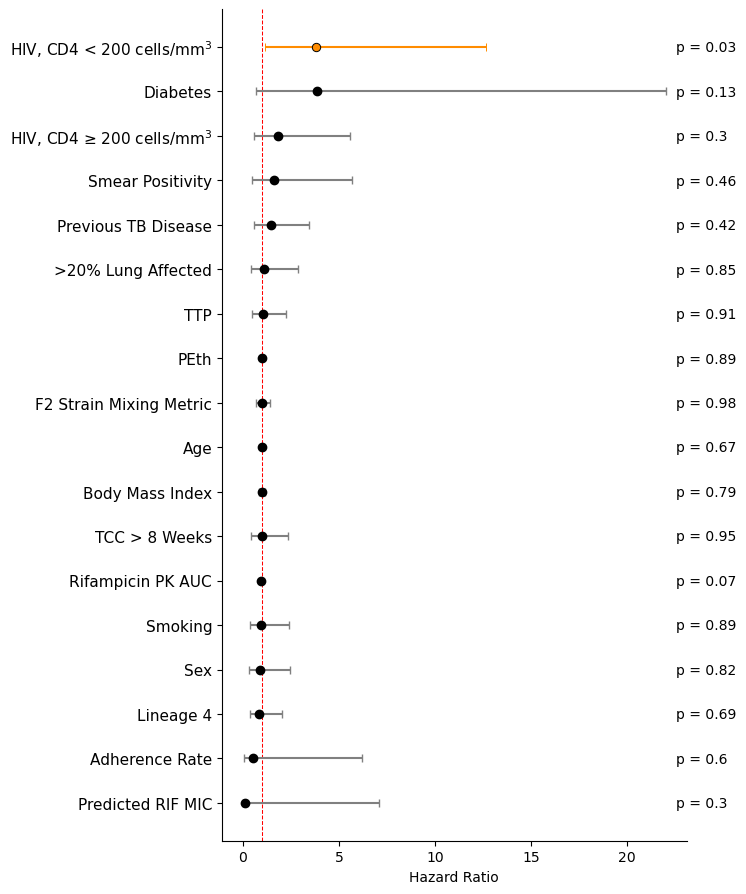

In [412]:
forest_plot(df_outcomes_binary_model_final.query("MIC_type=='predicted' & include_drugs=='RIF'"), labels_dict)#, log=True)